In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/customer_support_tickets.csv")

df.head()


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN


In [4]:
df.shape
df.columns
df.info()
df.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 61765 entries, 0 to 61764
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   subject   56466 non-null  str    
 1   body      61763 non-null  str    
 2   answer    48576 non-null  str    
 3   type      48587 non-null  str    
 4   queue     61765 non-null  str    
 5   priority  61765 non-null  str    
 6   language  61765 non-null  str    
 7   version   28587 non-null  float64
 8   tag_1     48587 non-null  str    
 9   tag_2     48528 non-null  str    
 10  tag_3     48356 non-null  str    
 11  tag_4     43990 non-null  str    
 12  tag_5     27636 non-null  str    
 13  tag_6     13225 non-null  str    
 14  tag_7     5968 non-null   str    
 15  tag_8     2472 non-null   str    
dtypes: float64(1), str(15)
memory usage: 57.2 MB


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
count,56466,61763,48576,48587,61765,61765,61765,28587.000000,48587,48528,48356,43990,27636,13225,5968,2472
unique,46635,53364,40139,4,52,5,2,NaN,211,350,591,831,956,920,755,512
top,Synchronisationsproblem,Support needed,Currently investigating the issue,Incident,Technical Support,medium,de,NaN,Security,Performance,IT,Tech Support,Tech Support,Tech Support,Tech Support,Documentation
freq,3,2,2,19444,14186,23378,33504,NaN,9156,8698,9430,10004,6904,2606,512,166
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,278.382027,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,165.962935,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,400.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,400.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df["language"].value_counts()

language
de    33504
en    28261
Name: count, dtype: int64

## Decision

Only English tickets will be used in the first version of the project.

Reasons:

- DistilBERT is optimized for English.
- Using one language simplifies preprocessing.
- Approximately 28,000 English tickets are available, which is sufficient for training.
- Multilingual support can be added in future versions using multilingual transformer models.

In [6]:
df = df[df["language"] == "en"].copy()

In [7]:
df.shape

(28261, 16)

In [8]:
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_percentage = (
    df.isnull().sum() / len(df) * 100
).sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": missing_percentage.round(2)
})

missing_df

,Missing Values,Percentage (%)
tag_8,26653,94.31
tag_7,24562,86.91
tag_6,20353,72.02
tag_5,11960,42.32
version,11923,42.19
subject,3639,12.88
tag_4,2584,9.14
tag_3,113,0.40
tag_2,16,0.06
answer,6,0.02


## Observations

The missing value analysis indicates that the dataset is largely complete for the features required in this project.

Several tag columns (`tag_5` to `tag_8`) contain a high percentage of missing values. Since these columns are not part of the initial modeling objective, they will be excluded from preprocessing and model training.

The `version` column also contains approximately 42% missing values. As product version is not required for ticket classification, this column will not be used in the first version of the project.

The `subject` column contains approximately 13% missing values. Rather than removing these records, missing subjects will be replaced with an empty string. This preserves valuable training examples while allowing the model to rely on the ticket body when the subject is unavailable.

The `body` column is nearly complete, with only one missing value. Since the body contains the primary textual information for classification, the single incomplete record will be removed.

The target columns (`priority`, `queue`, and `type`) contain no missing values, making them suitable for supervised learning without additional preprocessing.

In [9]:
# Duplicate Analysis

#Duplicate records can negatively impact model evaluation by causing data leakage between the training and test sets.

#In this section, we identify duplicate rows as well as duplicate tickets based on the textual content (`subject` and `body`). If duplicate tickets exist, we will decide whether they should be removed before training.

df.duplicated().sum()

df.duplicated(subset=["subject", "body"]).sum()

np.int64(4513)

In [10]:
print(f"Rows before removing duplicates: {len(df)}")

Rows before removing duplicates: 28261


In [11]:
df = df.drop_duplicates()

In [12]:
print(f"Rows after removing duplicates: {len(df)}")

Rows after removing duplicates: 28261


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
print("Exact duplicate rows:", df.duplicated().sum())

print(
    "Duplicate subject/body:",
    df.duplicated(subset=["subject", "body"]).sum()
)

Exact duplicate rows: 0
Duplicate subject/body: 4513


In [15]:
before = len(df)

df_no_duplicates = df.drop_duplicates()

after = len(df_no_duplicates)

print(f"Before: {before}")
print(f"After : {after}")
print(f"Removed: {before - after}")

Before: 28261
After : 28261
Removed: 0


In [16]:
duplicate_tickets = df[
    df.duplicated(subset=["subject", "body"], keep=False)
]

duplicate_tickets.head(10)

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
9992,Problem with Cross-User Data Synchronization,Users are facing difficulties in syncing proje...,Received an email about the issue with cross-u...,Incident,Product Support,low,en,400.0,Bug,Network,Performance,IT,Tech Support,NaN,NaN,NaN
9994,Enhance User Interface,The current UI is cumbersome. Please improve n...,Forwarding your feedback to the development te...,Change,Product Support,medium,en,400.0,Feature,Feedback,Documentation,NaN,NaN,NaN,NaN,NaN
10013,Report on Connectivity Problem,"To Customer Support, I am submitting a report ...","<name>, thank you for reporting the connectivi...",Incident,Customer Service,medium,en,400.0,Network,Performance,Outage,Disruption,IT,Tech Support,NaN,NaN
10015,Optimization of Investments Through Data Analy...,"Hello, inquiring about the data analytics serv...",Thank you for reaching out to our customer sup...,Request,Customer Service,medium,en,400.0,Feature,Performance,Documentation,Feedback,IT,Tech Support,NaN,NaN
10018,NaN,"Customer Support, inquiring about digital stra...","<name>, thanks for your interest in our digita...",Request,Technical Support,high,en,400.0,Feedback,Sales,Tech Support,NaN,NaN,NaN,NaN,NaN
10019,Requirements for Secure Data Protection Services,Could you please share details about secure da...,<name> offers secure data protection services ...,Request,Service Outages and Maintenance,high,en,400.0,Security,Documentation,IT,Tech Support,NaN,NaN,NaN,NaN
10025,Microsoft SQL Support,Seeking guidance on integrating project manage...,"Will provide API guides, setup tutorials, and ...",Request,Customer Service,medium,en,400.0,Documentation,IT,Tech Support,Performance,NaN,NaN,NaN,NaN
10033,Issue with Billing for Analytical Services,"Hello, I am writing to address the discrepanci...","Dear [Customer Name], we acknowledge your emai...",Problem,Billing and Payments,medium,en,400.0,Billing,Payment,Refund,Disruption,NaN,NaN,NaN,NaN
10036,Assistance Required for Integrating Asana with...,I need guidance on how to integrate Asana with...,Please provide the integration steps and requi...,Request,Product Support,medium,en,400.0,Feature,Documentation,IT,Tech Support,NaN,NaN,NaN,NaN
10038,Concern Regarding Security of Hospital System,A data breach has been identified in the hospi...,We are in contact regarding the security conce...,Incident,IT Support,medium,en,400.0,Security,Bug,IT,Tech Support,NaN,NaN,NaN,NaN


In [17]:
duplicate_tickets.groupby(["subject", "body"]).size().sort_values(ascending=False).head(10)

subject                                                                                                body                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        
 Reported Problem with Data Access                                                                     Faced data access problems after the software update, which might be related to Scikit-learn and Oracle Database incompatibility.                                                            

In [18]:
duplicate_tickets[
    ["subject", "body", "priority", "queue", "type"]
].sort_values(["subject", "body"]).head(20)

,subject,body,priority,queue,type
18651,Reported Problem with Data Access,Faced data access problems after the software ...,medium,Product Support,Problem
59471,Reported Problem with Data Access,Faced data access problems after the software ...,medium,Product Support,Problem
16189,Urgent Support Required for Project Managemen...,Our project management platform is currently f...,high,Technical Support,Incident
60388,Urgent Support Required for Project Managemen...,Our project management platform is currently f...,high,Technical Support,Incident
18423,API Integration Support Request,I am interested in learning about the API inte...,high,Technical Support,Request
51226,API Integration Support Request,I am interested in learning about the API inte...,high,Technical Support,Request
15272,AR Brille Oracle Support,Is it possible to provide comprehensive docume...,high,Technical Support,Request
43314,AR Brille Oracle Support,Is it possible to provide comprehensive docume...,high,Technical Support,Request
27730,Ableton Live 11 Suite Integrations,Seeking to understand the integrations availab...,low,Technical Support,Request
59840,Ableton Live 11 Suite Integrations,Seeking to understand the integrations availab...,low,Technical Support,Request


In [19]:
first_group = (
    duplicate_tickets[["subject", "body"]]
    .drop_duplicates()
    .iloc[0]
)

first_group

subject         Problem with Cross-User Data Synchronization
body       Users are facing difficulties in syncing proje...
Name: 9992, dtype: str

In [20]:
subject = first_group["subject"]
body = first_group["body"]

duplicate_tickets[
    (duplicate_tickets["subject"] == subject) &
    (duplicate_tickets["body"] == body)
]

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
9992,Problem with Cross-User Data Synchronization,Users are facing difficulties in syncing proje...,Received an email about the issue with cross-u...,Incident,Product Support,low,en,400.0,Bug,Network,Performance,IT,Tech Support,NaN,NaN,NaN
46453,Problem with Cross-User Data Synchronization,Users are facing difficulties in syncing proje...,Received an email concerning the issue with cr...,Incident,Product Support,low,en,NaN,Bug,Network,Performance,IT,Tech Support,NaN,NaN,NaN


## Duplicate Analysis

The initial analysis found no exact duplicate rows in the English subset of the dataset. However, **4,513 records shared identical `subject` and `body` values**.

A detailed investigation showed that these records differed only in metadata fields such as the support agent's response (`answer`) and the product `version`, while the modeling columns (`subject`, `body`, `priority`, `queue`, and `type`) remained identical.

Since the objective of this project is to predict ticket metadata from the customer ticket text, duplicate removal will be performed using only the columns relevant to the machine learning task. This ensures that repeated training examples do not bias the model while preserving genuinely distinct tickets.

In [21]:
model_columns = [
    "subject",
    "body",
    "priority",
    "queue",
    "type"
]

df = df.drop_duplicates(subset=model_columns)

# 7. Text Analysis

The performance of any Natural Language Processing (NLP) model depends heavily on the characteristics of the input text.

In this section, we analyze the textual features of the customer support tickets.

The objectives are:

- Measure the length of ticket subjects.
- Measure the length of ticket bodies.
- Identify unusually short or long tickets.
- Understand how ticket length may influence model selection and preprocessing.

These insights will help determine whether the text needs cleaning, truncation, or additional preprocessing before training the machine learning models.

In [22]:
df["subject_length"] = df["subject"].fillna("").str.len()

df["body_length"] = df["body"].fillna("").str.len()

In [23]:
df["subject_length"].describe()

count    23748.000000
mean        38.225914
std         20.359744
min          0.000000
25%         29.000000
50%         39.000000
75%         50.000000
max        258.000000
Name: subject_length, dtype: float64

In [24]:
df["body_length"].describe()

count    23748.000000
mean       376.388201
std        207.302821
min          0.000000
25%        205.000000
50%        372.000000
75%        537.000000
max       1793.000000
Name: body_length, dtype: float64

In [25]:
df["subject_word_count"] = (
    df["subject"]
    .fillna("")
    .str.split()
    .str.len()
)

df["body_word_count"] = (
    df["body"]
    .fillna("")
    .str.split()
    .str.len()
)

In [26]:
df["subject_word_count"].describe()

count    23748.000000
mean         5.032971
std          2.732877
min          0.000000
25%          4.000000
50%          5.000000
75%          7.000000
max         37.000000
Name: subject_word_count, dtype: float64

In [27]:
df["body_word_count"].describe()

count    23748.000000
mean        56.142244
std         31.939809
min          0.000000
25%         30.000000
50%         55.000000
75%         79.000000
max        272.000000
Name: body_word_count, dtype: float64

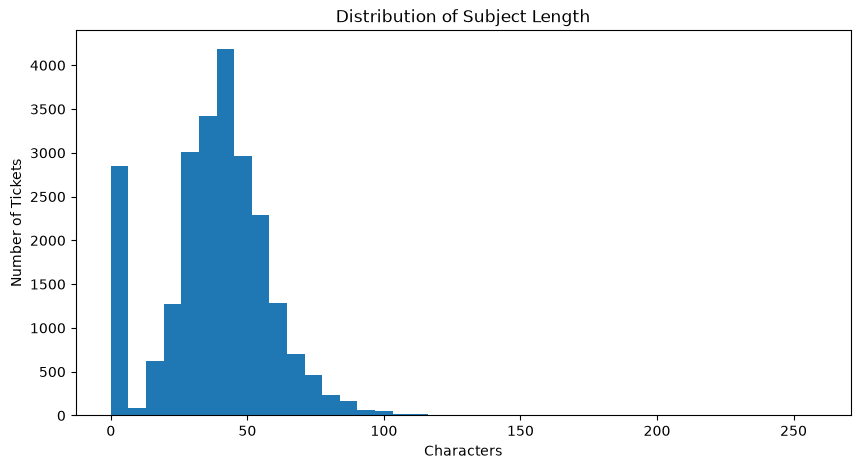

In [28]:
plt.figure(figsize=(10,5))

plt.hist(df["subject_length"], bins=40)

plt.title("Distribution of Subject Length")

plt.xlabel("Characters")

plt.ylabel("Number of Tickets")

plt.show()

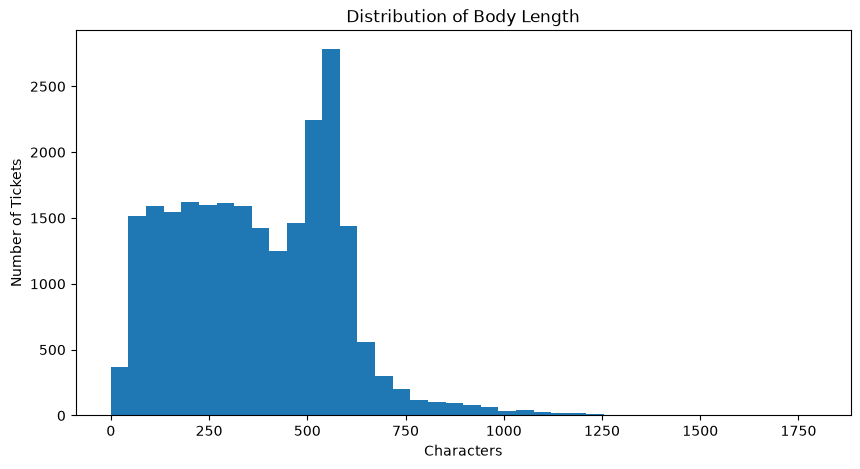

In [30]:
plt.figure(figsize=(10,5))

plt.hist(df["body_length"], bins=40)

plt.title("Distribution of Body Length")

plt.xlabel("Characters")

plt.ylabel("Number of Tickets")

plt.show()

In [31]:
df.nlargest(
    5,
    "body_length"
)[
    [
        "subject",
        "body",
        "body_length",
        "body_word_count"
    ]
]

,subject,body,body_length,body_word_count
58369,Problem with Inaccurate Invoice,"Dear Customer Support,\n\nI am writing to expr...",1793,272
46318,Refresh Digital Marketing Strategy for Enhance...,"Dear Customer Support,\n\nI am contacting you ...",1748,239
48281,NaN,"Dear Customer Support, <br><br>I am contacting...",1702,257
42297,Support for Integrating Firebase on macOS,"Hello [Your Name],\n\nI hope this message find...",1672,251
49678,NaN,"Hello Customer Support,\n\nI hope this message...",1606,253


In [32]:
df.nsmallest(
    5,
    "body_length"
)[
    [
        "subject",
        "body",
        "body_length",
        "body_word_count"
    ]
]

,subject,body,body_length,body_word_count
59452,Moodle integration broke unexpectedly due to a...,NaN,0,0
42314,NaN,Help,4,1
7607,Experiencing Downtime on Multiple Platforms,System,6,1
1103,Facing System Downtime on Multiple Platforms,Our system,10,2
54460,Concerns Regarding Hospital Data Security,Seeking Help,12,2


## Observations

The textual characteristics of the dataset were analyzed using both character counts and word counts.

### Subject

- The average subject length is **38 characters** (approximately **5 words**).
- The distribution is relatively symmetric, indicating consistent subject lengths.
- A small number of subjects have zero length due to missing values that were temporarily replaced with empty strings for analysis.

### Body

- The average body length is **376 characters** (approximately **56 words**).
- Most ticket bodies fall between **200 and 600 characters**, indicating that customer support requests are generally concise.
- The distribution exhibits a slight right skew caused by a small number of unusually long tickets.
- The longest ticket contains **1,793 characters (272 words)**, which is still within a reasonable range for transformer-based models after tokenization.

### Engineering Decisions

Based on the analysis:

- Missing subjects will not be removed because the ticket body contains sufficient information for classification.
- Rows with empty ticket bodies will be removed during preprocessing because they do not provide meaningful textual information.
- Subject and body text will later be combined into a single input sequence before training.
- The observed ticket lengths indicate that DistilBERT should be able to process the vast majority of tickets without significant truncation.